# Description
```
Name      : project_fire_detection_2
Problem   : Classification
Type      : Deep learning
Algorithm : Convolutional neural network : CNN
Formula   : Weightes-Sum
Action    : Relu | softmax
Loss      : Cross-Entropy-Binary
Train     : Supervised
Input     : Feature and label
Output    : Binary
Dataset   : Unstructured : fire_dataset
```

# General

### Import

In [ ]:
import glob
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
from keras import models, layers
from keras.models import load_model

### Variable

In [41]:
root_dir = '/Volumes/data/documents/ai_document'

# Dataset

### Data

In [ ]:
dataset = []
for address in glob.glob(f"{root_dir}/dataset/fire_dataset/**/*.png", recursive=True):
    img = cv.imread(address)
    dataset.append(img)

print("len: {}".format(len(dataset)))

len: 998


### Label

#### Split

In [43]:
labels = []
for address in glob.glob(f"{root_dir}/dataset/fire_dataset/**/*.png", recursive=True):
    label = address.split('/')[-1].split('.')[0]
    labels.append(label)

print("len: {}".format(len(labels)))

len: 998


#### Convert label to encoding

In [44]:
le = LabelEncoder()
labels = le.fit_transform(labels)
labels = to_categorical(labels)

# Preprocessing

In [45]:
data = []
for img in dataset:
    #---Resize
    img = cv.resize(img, (32, 32))
    #---Normalization
    img = img/255.0
    #---Add
    data.append(img)
#---Convert
data = np.array(data)

print("Shape: {}".format(data.shape))

Shape: (998, 32, 32, 3)


# Separate tarin and test

In [47]:
x_train, x_test, y_train, y_test = train_test_split(data, labels, test_size=0.2)
print(x_train.shape)
print(x_test.shape)
print(len(y_train))
print(len(y_test))

(798, 32, 32, 3)
(200, 32, 32, 3)
798
200


# Model

In [48]:
mdl = models.Sequential()

mdl.add(layers.Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)))
mdl.add(layers.MaxPool2D((2, 2)))

mdl.add(layers.Conv2D(32, (3, 3), activation="relu"))
mdl.add(layers.MaxPool2D((2, 2)))
 
mdl.add(layers.Flatten())

mdl.add(layers.Dense(100, activation="relu"))
mdl.add(layers.Dense(2, activation="softmax"))

mdl.compile(optimizer="SGD", loss="binary_crossentropy", metrics=["accuracy"])

mdl.summary()

/Volumes/data/documents/ai_document/.myenv3/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       115,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           202 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,646 (490.80 KB)

 Trainable params: 125,646 (490.80 KB)

 Non-trainable params: 0 (0.00 B)

# Train

In [49]:
EPOCHS = 20
BATCH_SIZE = 16
output_label = ['fire', 'nofire']
h = mdl.fit(x_train, y_train ,batch_size=BATCH_SIZE, epochs=EPOCHS, validation_data=(x_test, y_test))

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6840 - loss: 0.6358 - val_accuracy: 0.8000 - val_loss: 0.4835
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7322 - loss: 0.5338 - val_accuracy: 0.8000 - val_loss: 0.4366
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7540 - loss: 0.4541 - val_accuracy: 0.8050 - val_loss: 0.3726
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7401 - loss: 0.4074 - val_accuracy: 0.9000 - val_loss: 0.3159
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8706 - loss: 0.3286 - val_accuracy: 0.8850 - val_loss: 0.2990
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9044 - loss: 0.2672 - val_accuracy: 0.9050 - val_loss: 0.2245
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9387 - loss: 0.2113 - val_accuracy: 0.9050 - val_loss: 0.2152
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9354 - loss: 0.1983 - val_accuracy: 0.8650 - val_loss:

# Evaluation

### Loss and Accuracy

In [50]:
loss, accuracy = mdl.evaluate(x_test, y_test)
print("Loss: {:.2f} | Accuracy: {:.2f}".format(loss, accuracy))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9614 - loss: 0.1227 
Loss: 0.13 | Accuracy: 0.94


### History

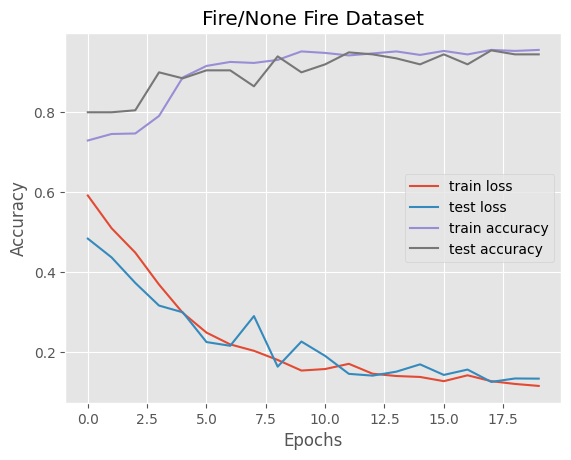

In [51]:
plt.style.use('ggplot')
plt.plot(h.history['loss'], label='train loss')
plt.plot(h.history['val_loss'], label='test loss')
plt.plot(h.history['accuracy'], label='train accuracy')
plt.plot(h.history['val_accuracy'], label='test accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Fire/None Fire Dataset')
plt.show()

# Save model

In [52]:
mdl.save(f"{root_dir}/dataset/cnn_1.h5")

# Test

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
01.jpg : nofire


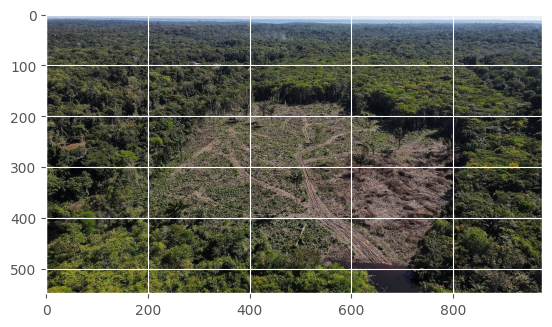

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
03.jpg : fire


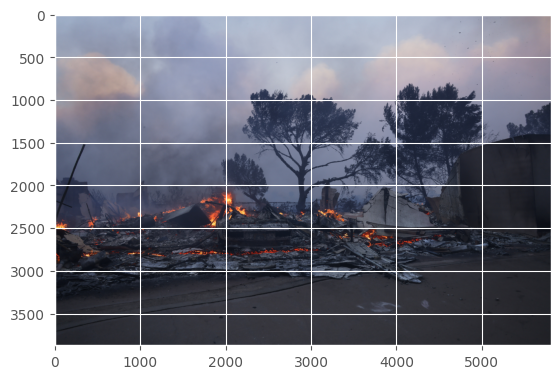

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
02.jpg : nofire


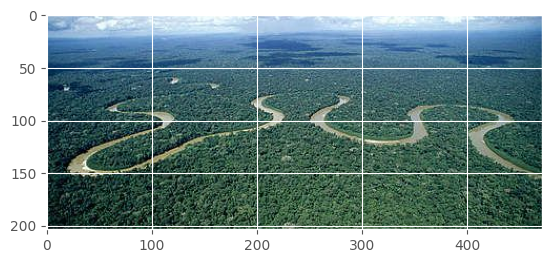

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
07.jpg : nofire


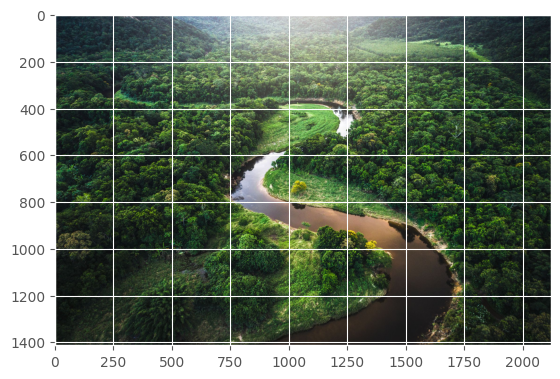

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
05.jpg : nofire


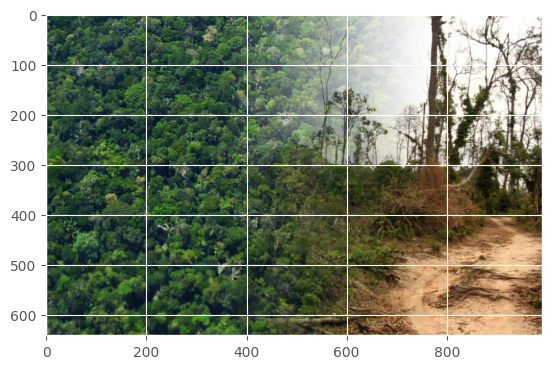

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
04.jpg : fire


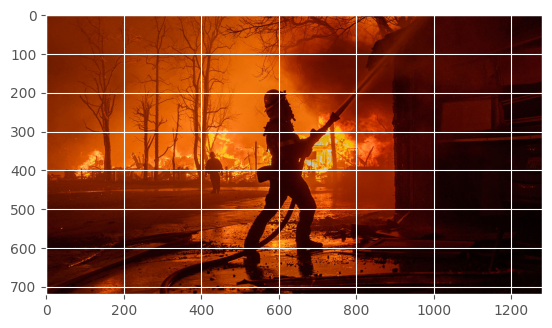

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
08.jpg : fire


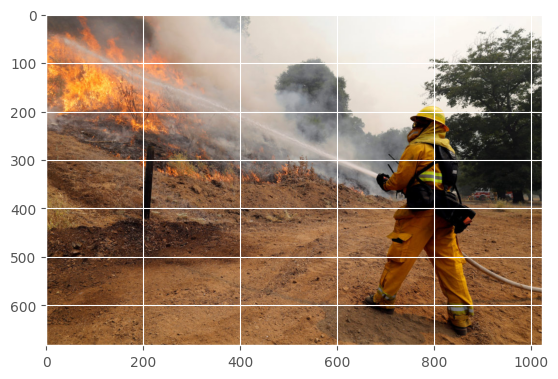

In [55]:
mdl = load_model(f"{root_dir}/dataset/cnn_1.h5")
for address in glob.glob(f"{root_dir}/dataset/fire_dataset/predict/*.jpg"):
    img = cv.imread(address)
    img = cv.resize(img, (32, 32))
    img = img/255.0
    img = np.array([img])
    pred = mdl.predict(img)[0]
    pred_max = np.argmax(pred)
    out = output_label[pred_max]
    name = address.split('/')[-1].split('.')[0]
    print("{}.jpg : {}".format(name, out))

    img = cv.imread(address)
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.show()
